# ***Introduction:***
As we saw in slides, the AutoEncoders are a specific type of feedforward neural networks! In this case the input is the same as the output. We use dimension reduction using the code part after the input and then we try to catch it again from the output part!

We have 3 parts:
* Encoder
* Code
* Decoder

The encoder compresses the input and produces the code, the decoder then reconstructs the input only using this code.

To build an AutoEncoder we need 3 things:
* Encoding method
* Decoding method
* Loss function to compare the output with the target.

So now we know all we want. Let's continue step by step...

# ***Import Libraries:***

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from __future__ import print_function
from keras.models import Model
from keras.layers import Dense, Input
from keras.datasets import mnist
from keras.regularizers import l1
from keras.optimizers import Adam

# ***Implementation:***

There are 4 hyperparameters that we need to set before training an AutoEncoder:
* Code size
* Number of layers
* Number of nodes per layer
* Loss function


In [ ]:
(xTrain, yTrain), (xTest, yTest) = mnist.load_data()

xTrain = xTrain.astype("float32") / 255.0
xTest = xTest.astype("float32") / 255.0
xTrain = xTrain.reshape((len(xTrain), np.prod(xTrain.shape[1:])))
xTest = xTest.reshape((len(xTest), np.prod(xTest.shape[1:])))
print(xTrain.shape)
print(xTest.shape)


(60000, 784)
(10000, 784)


In [ ]:
InputSize = 784
HiddenSize = 128
CodeSize = 32

InputImage = Input(shape = (InputSize,))
FirstHidden = Dense(HiddenSize, activation = "relu")(InputImage)
Code = Dense(CodeSize, activation = "relu")(FirstHidden)
SecondHidden = Dense(HiddenSize, activation = "relu")(Code)
OutputImage = Dense(InputSize, activation = "sigmoid")(SecondHidden)
AutoEncoder = Model(InputImage, OutputImage)
AutoEncoder.compile(optimizer = "adam", loss = "binary_crossentropy")
AutoEncoder.fit(xTrain, xTrain, epochs = 3)

Epoch 1/3
1875/1875 [==============================] - 11s 6ms/step - loss: 0.1390
Epoch 2/3
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0991
Epoch 3/3
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0934


313/313 [==============================] - 1s 4ms/step


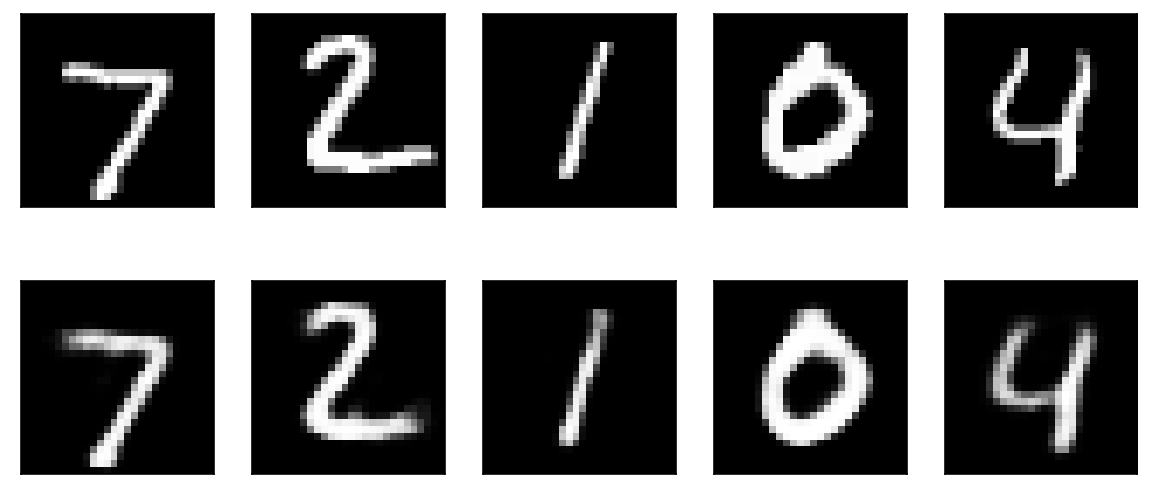

In [ ]:
def PlotAutoencoderOutputs(AutoEncoder, n, dims):
    decoded_imgs = AutoEncoder.predict(xTest)
    #Number of example digits to show
    n = 5
    plt.figure(figsize=(10, 4.5))
    for i in range(n):
        #Plot original image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(xTest[i].reshape(*dims))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        #Plot reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(*dims))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.show()

PlotAutoencoderOutputs(AutoEncoder, 5, (28, 28))

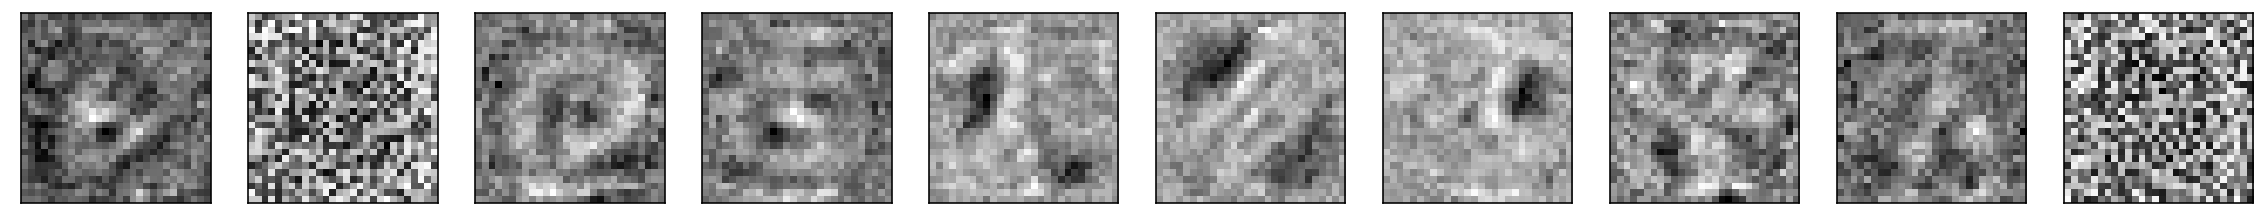

In [ ]:
Weights = AutoEncoder.get_weights()[0].T
n = 10
plt.figure(figsize = (20, 5))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(Weights[i+0].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

# ***Ways to force the autoencoder to learn useful features:***
* Keeping the code layer small
* Adding random noise to its inputs and making it recover the original noise-free data
* Using regularization

# ***Denoising AutoEncoder:***

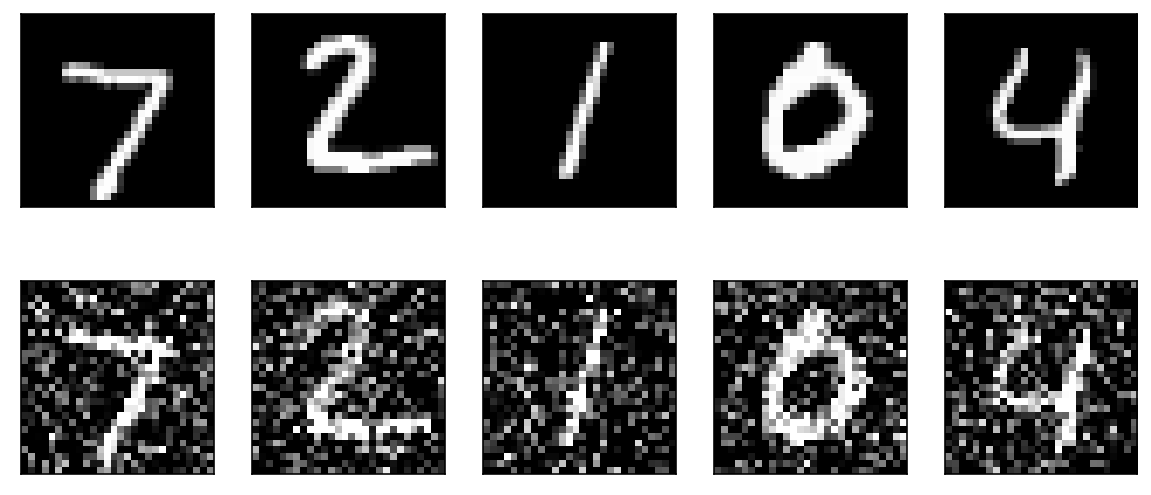

In [ ]:
NoiseFactor = 0.4
TrainNoisyX = xTrain + NoiseFactor * np.random.normal(size = xTrain.shape)
TestNoisyX = xTest + NoiseFactor * np.random.normal(size = xTest.shape)
TrainNoisyX = np.clip(TrainNoisyX, 0.0, 1.0)
TestNoisyX = np.clip(TestNoisyX, 0.0, 1.0)
n = 5
plt.figure(figsize = (10, 4.5))

for i in range(n):
    #Plot original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(xTest[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

for i in range(n):
    #Plot noisy images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(TestNoisyX[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

In [ ]:
InputSize = 784
HiddenSize = 128
CodeSize = 32

InputImage = Input(shape = (InputSize,))
FirstHidden = Dense(HiddenSize, activation = "relu")(InputImage)
Code = Dense(CodeSize, activation = "relu")(FirstHidden)
SecondHidden = Dense(HiddenSize, activation = "relu")(Code)
OutputImage = Dense(InputSize, activation = "sigmoid")(SecondHidden)
AutoEncoder = Model(InputImage, OutputImage)
AutoEncoder.compile(optimizer = "adam", loss = "binary_crossentropy")
AutoEncoder.fit(TrainNoisyX, xTrain, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.1649
Epoch 2/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.1297
Epoch 3/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1231
Epoch 4/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1197
Epoch 5/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1175
Epoch 6/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1160
Epoch 7/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1148
Epoch 8/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1136
Epoch 9/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1127
Epoch 10/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1119


313/313 [==============================] - 1s 4ms/step
The plots are : 
 1. Original Images 
 2. Noisy Input 
 3. AutoEncoder Output


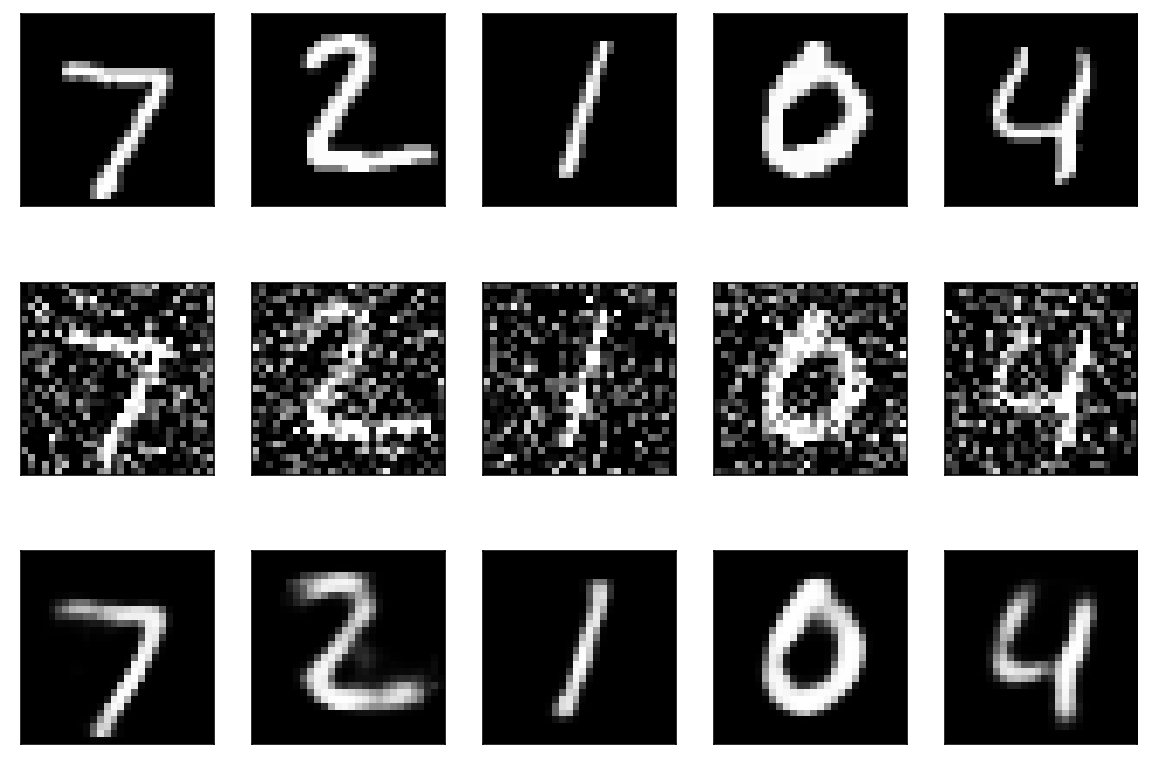

In [ ]:
n = 5
plt.figure(figsize=(10, 7))
Images = AutoEncoder.predict(TestNoisyX)
print("The plots are : \n 1. Original Images \n 2. Noisy Input \n 3. AutoEncoder Output")
for i in range(n):
    #Plot original image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(xTest[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    #Plot noisy image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(TestNoisyX[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    #Plot noisy image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(Images[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

We can make our output better by using more complex autoencoder architecture, such as **convolutional autoencoders**.

# ***Loss Function:***

In [ ]:
def PlotLoss(history):
    historydf = pd.DataFrame(history.history, index = history.epoch)
    plt.figure(figsize = (8, 6))
    historydf.plot(ylim = (0, historydf.values.max()))
    plt.title("Loss: %.3f" % history.history["loss"][-1])
def PlotCompareHistories(history_list , name_list , plot_accuracy = True):
    dflist = []
    min_epoch = len(history_list[0].epoch)
    losses = []
    for history in history_list:
        h = {key: val for key, val in history.history.items() if not key.startswith("val_")}
        dflist.append(pd.DataFrame(h, index=history.epoch))
        min_epoch = min(min_epoch, len(history.epoch))
        losses.append(h["loss"][-1])
    historydf = pd.concat(dflist, axis = 1)
    metrics = dflist[0].columns
    idx = pd.MultiIndex.from_product([name_list, metrics], names = ["model", "metric"])
    historydf.columns = idx
    plt.figure(figsize = (6, 8))
    ax = plt.subplot(211)
    historydf.xs("loss", axis = 1, level = "metric").plot(ylim = (0,1), ax = ax)
    plt.title("Training Loss: " + " vs ".join([str(round(x, 3)) for x in losses]))
    if plot_accuracy:
        ax = plt.subplot(212)
        historydf.xs("acc", axis = 1, level = "metric").plot(ylim = (0,1), ax = ax)
        plt.title("Accuracy")
        plt.xlabel("Epochs")

    plt.xlim(0, min_epoch-1)
    plt.tight_layout()

In [ ]:
AutoEncoder = Model(InputImage, OutputImage)
AutoEncoder.compile(optimizer = "adam", loss = "binary_crossentropy")
AutoEncoder.fit(TrainNoisyX, xTrain, epochs = 10)
HistoryNoisy = AutoEncoder.fit(xTrain, xTrain, epochs = 20)
EncodedNoisy = Model(InputImage , Code)

Epoch 1/10
1875/1875 [==============================] - 11s 5ms/step - loss: 0.1114
Epoch 2/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1108
Epoch 3/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1103
Epoch 4/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1099
Epoch 5/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1095
Epoch 6/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1092
Epoch 7/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1086
Epoch 8/10
1875/1875 [==============================] - 14s 8ms/step - loss: 0.1081
Epoch 9/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.1077
Epoch 10/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1074
Epoch 1/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0931
Epoch 2/20
1875/1875 [==============================] - 11s 6ms/step - loss:

313/313 [==============================] - 1s 2ms/step


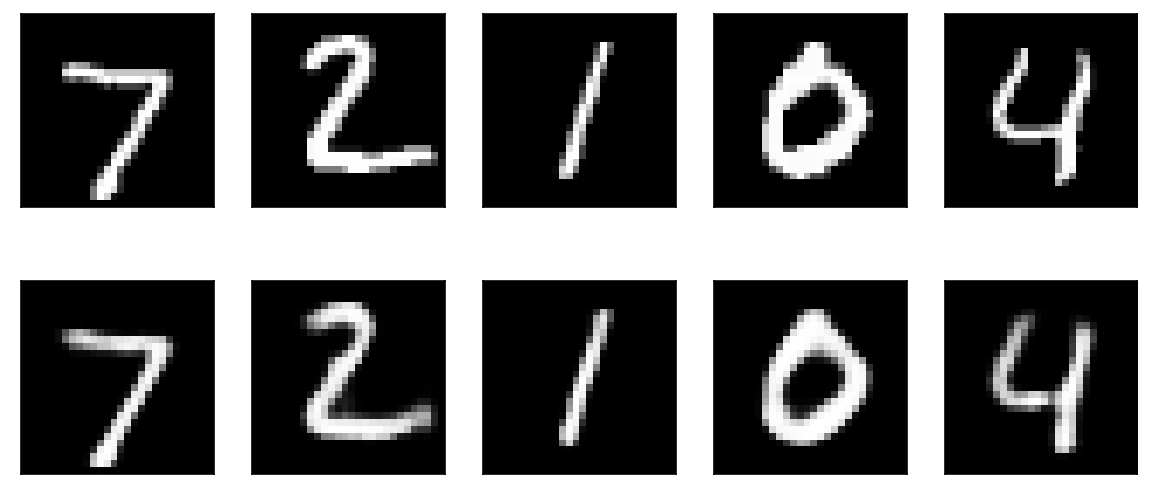

In [ ]:
PlotAutoencoderOutputs(AutoEncoder, 5, (28, 28))

In [ ]:
InputSize = 784
CodeSize = 32

InputImage = Input(shape=(InputSize,))
code = Dense(CodeSize , activation = "relu")(InputImage)
OutputImage = Dense(InputSize, activation = "sigmoid")(code)
StandardAutoEncoder = Model(InputImage, OutputImage)
StandardAutoEncoder.compile(optimizer = "adam", loss = "binary_crossentropy")
HistoryStandard = StandardAutoEncoder.fit(xTrain, xTrain, epochs = 20)
EncodedStandard = Model(InputImage, code)

Epoch 1/20
1875/1875 [==============================] - 8s 4ms/step - loss: 0.1606
Epoch 2/20
1875/1875 [==============================] - 12s 6ms/step - loss: 0.1036
Epoch 3/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0967
Epoch 4/20
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0954
Epoch 5/20
1875/1875 [==============================] - 7s 3ms/step - loss: 0.0947
Epoch 6/20
1875/1875 [==============================] - 7s 3ms/step - loss: 0.0944
Epoch 7/20
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0941
Epoch 8/20
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0939
Epoch 9/20
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0938
Epoch 10/20
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0937
Epoch 11/20
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0936
Epoch 12/20
1875/1875 [==============================] - 7s 3ms/step - loss: 0.0936


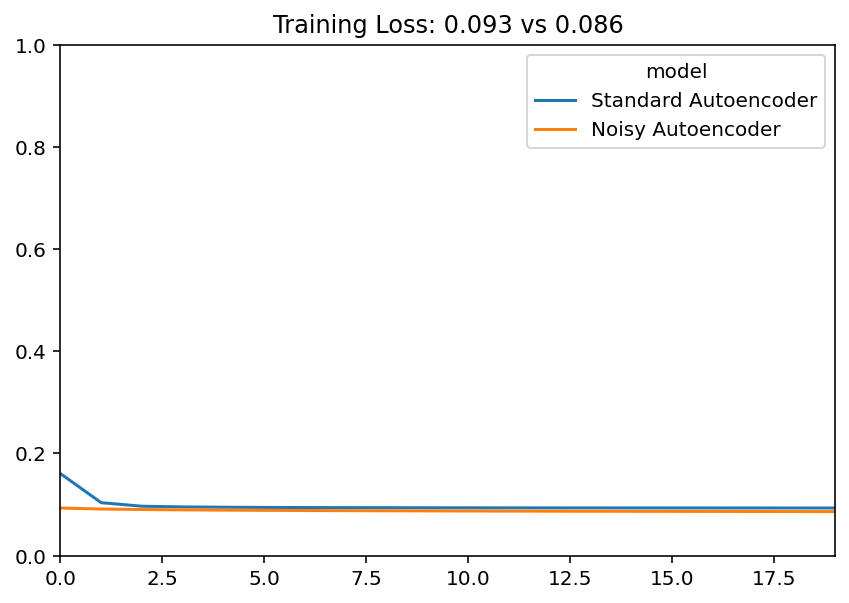

In [ ]:
PlotCompareHistories([HistoryStandard, HistoryNoisy], ["Standard Autoencoder", "Noisy Autoencoder"], plot_accuracy = False)

In [ ]:
StandardAutoEncoder.evaluate(xTest, xTest)

313/313 [==============================] - 2s 6ms/step - loss: 0.0922


0.0922495424747467

In [ ]:
AutoEncoder.evaluate(xTest, xTest) #Noisy one

313/313 [==============================] - 2s 6ms/step - loss: 0.0857


0.08569847792387009

In [ ]:
print(EncodedStandard.predict(xTest).mean())
print(EncodedNoisy.predict(xTest).mean())

313/313 [==============================] - 1s 2ms/step
6.575983
313/313 [==============================] - 1s 2ms/step
4.407202


If we look at the histogram of code values for the images in the test set, the distribution is as follows:

313/313 [==============================] - 0s 2ms/step
The blue one is for standard and the orange one is the noisy one.


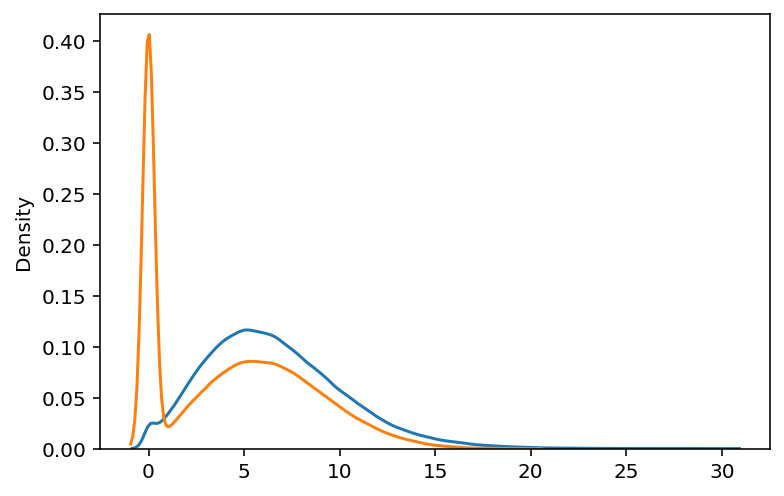

In [ ]:
import warnings
warnings.filterwarnings('ignore')
StandardScores = EncodedStandard.predict(xTest).ravel()
NoisyScores = EncodedNoisy.predict(xTest).ravel()
sns.distplot(StandardScores, hist = False, label = "Standard model")
sns.distplot(NoisyScores, hist = False, label = "Noisy model")
print("The blue one is for standard and the orange one is the noisy one.")

Noisy model:


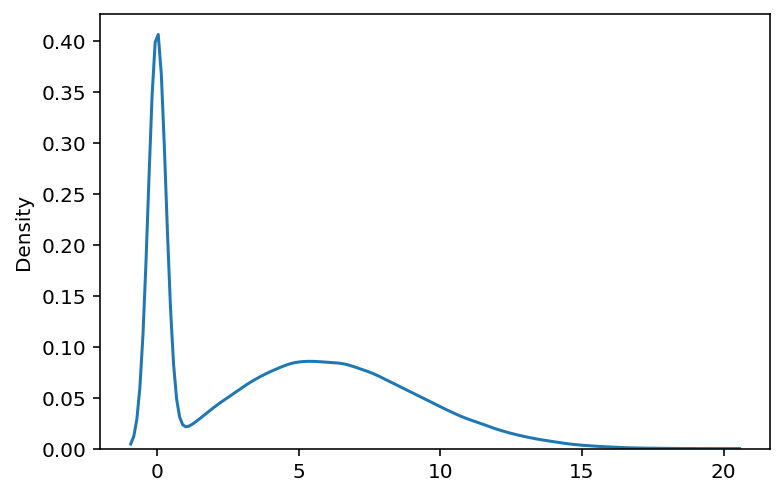

In [ ]:
sns.distplot(NoisyScores , hist = False)
print("Noisy model:")